In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

COLORS = plt.cm.tab10.colors  # cycles for however many runs N_LATEST_RUNS ends up being

In [2]:
runs_dir = Path("runs/test_cn")
N_LATEST_RUNS = 4


def find_n_latest_runs(prefix="predict_gene_expression_", runs_dir=runs_dir, n=1):
    candidates = [p for p in runs_dir.iterdir() if p.is_dir() and p.name.startswith(prefix)]
    if not candidates:
        raise FileNotFoundError(f"No runs found in {runs_dir} matching prefix={prefix!r}")
    return sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)[:n]


# Load only the artifacts predict_gene_expression.py already saves (config,
# training history, per-gene metrics) - no need to reload data or the model
# itself just to compare runs, so this stays fast no matter how many runs.
runs = []
for run_dir in find_n_latest_runs(n=N_LATEST_RUNS):
    config = json.loads((run_dir / "config.json").read_text())
    history_df = pd.read_csv(run_dir / "history.csv")
    per_gene_df = pd.read_csv(run_dir / "val_per_gene_metrics.csv")
    runs.append(dict(
        name=run_dir.name, run_dir=run_dir, config=config,
        history_df=history_df, per_gene_df=per_gene_df,
        mean_r2=float(per_gene_df["r2"].mean()),
    ))

runs.sort(key=lambda r: r["mean_r2"], reverse=True)
print(f"Comparing {len(runs)} runs from '{runs_dir}', ranked best -> worst by mean R²:")
for r in runs:
    print(f"  {r['mean_r2']:.4f}  {r['name']}")

Comparing 4 runs from 'runs\test_cn', ranked best -> worst by mean R²:
  0.3091  predict_gene_expression_20260909_142900
  0.2894  predict_gene_expression_20260909_142410
  0.2755  predict_gene_expression_20260909_142607
  0.2307  predict_gene_expression_20260909_142812


## Overview: mean R² per run

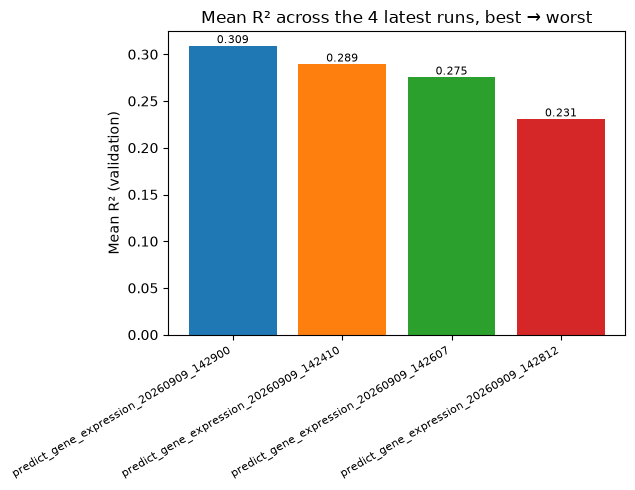

In [3]:
fig, ax = plt.subplots(figsize=(max(6, len(runs) * 1.6), 5))
bar_colors = [COLORS[i % len(COLORS)] for i in range(len(runs))]
bars = ax.bar(range(len(runs)), [r["mean_r2"] for r in runs], color=bar_colors)
ax.set_xticks(range(len(runs)))
ax.set_xticklabels([r["name"] for r in runs], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Mean R² (validation)")
ax.set_title(f"Mean R² across the {len(runs)} latest runs, best → worst")
for bar, r in zip(bars, runs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{r['mean_r2']:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

## Leaderboard: what's different between these runs, and how did each do?

Only shows config fields that actually differ between the runs being compared (fixed settings like `n_target_genes` are left out to keep this readable) alongside each run's key performance metrics.

In [4]:
all_keys = sorted(set(k for r in runs for k in r["config"]))
skip_keys = {"best_epoch", "stopped_early", "pretrain_best_epoch", "pretrain_val_r2"}  # shown separately below
differing_keys = [
    k for k in all_keys if k not in skip_keys
    and len({json.dumps(r["config"].get(k), sort_keys=True) for r in runs}) > 1
]

leaderboard = pd.DataFrame([
    {
        "run": r["name"],
        **{k: r["config"].get(k) for k in differing_keys},
        "best_epoch": r["config"].get("best_epoch"),
        "mean_r2": r["mean_r2"],
        "median_r2": float(r["per_gene_df"]["r2"].median()),
        "r2_gt_0.5": int((r["per_gene_df"]["r2"] > 0.5).sum()),
        "r2_lt_0": int((r["per_gene_df"]["r2"] < 0).sum()),
    }
    for r in runs
])
leaderboard

,run,input_source,n_input_features,n_samples,best_epoch,mean_r2,median_r2,r2_gt_0.5,r2_lt_0
0,predict_gene_expression_20260909_142900,"subtype,cn",4298,1105,77,0.309097,0.294471,1112,53
1,predict_gene_expression_20260909_142410,all,8930,1105,71,0.289394,0.273313,822,55
2,predict_gene_expression_20260909_142607,subtype,330,1643,49,0.275469,0.259309,755,70
3,predict_gene_expression_20260909_142812,"subtype,mutation",7857,1643,92,0.230706,0.215075,361,138


## Training curves

Each run's `history.csv` only covers its own fine-tuning phase (epoch 1 = first epoch of the saved model's training) - for a `pretrain_subtype` run, the pretraining stage happened before this and is intentionally not concatenated here, since it's a different model with different inputs.

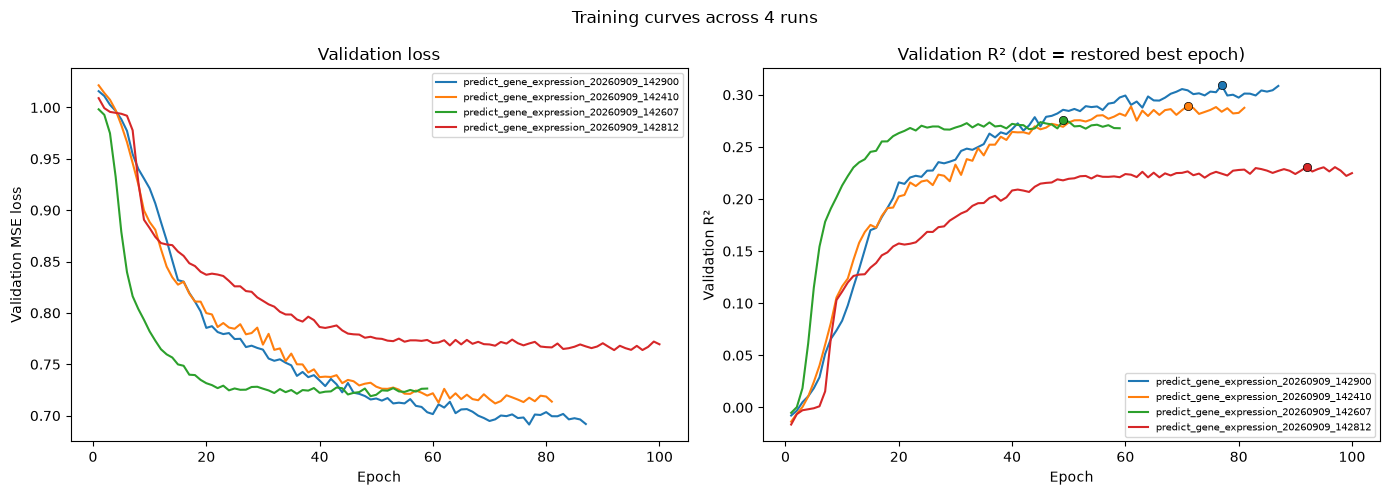

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, r in enumerate(runs):
    h, color = r["history_df"], COLORS[i % len(COLORS)]
    axes[0].plot(h["epoch"], h["val_loss"], label=r["name"], color=color)
    axes[1].plot(h["epoch"], h["val_r2"], label=r["name"], color=color)
    best_row = h.loc[h["epoch"] == r["config"].get("best_epoch", h["epoch"].iloc[-1])]
    if len(best_row):
        axes[1].scatter(best_row["epoch"], best_row["val_r2"], color=color, zorder=5, edgecolor="black", linewidth=0.5)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation MSE loss"); axes[0].set_title("Validation loss")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation R²"); axes[1].set_title("Validation R² (dot = restored best epoch)")
axes[0].legend(fontsize=7); axes[1].legend(fontsize=7)
fig.suptitle(f"Training curves across {len(runs)} runs")
plt.tight_layout()
plt.show()

## Per-gene R² distribution

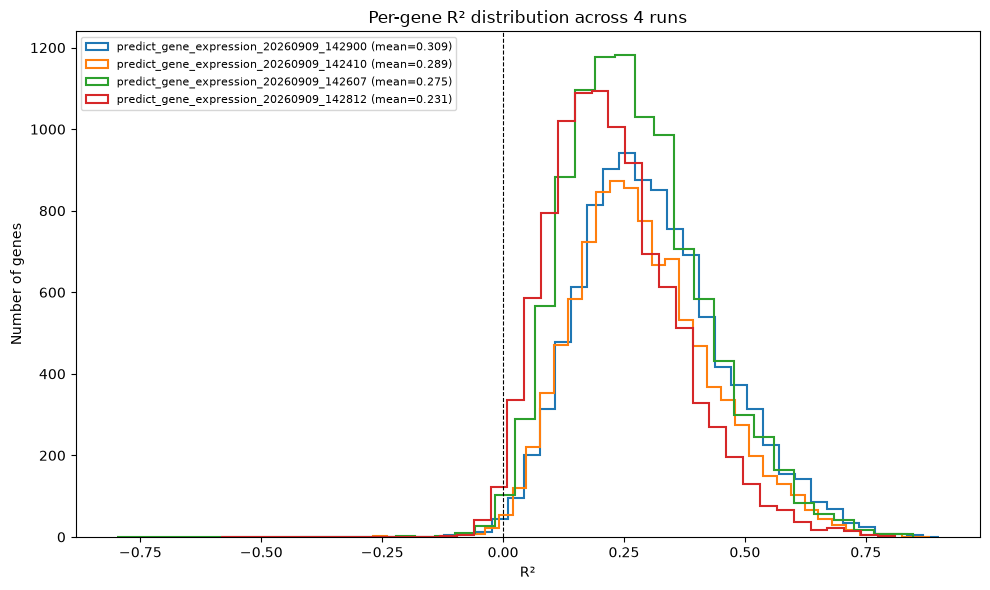

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
for i, r in enumerate(runs):
    ax.hist(
        r["per_gene_df"]["r2"], bins=40, histtype="step", linewidth=1.5,
        label=f"{r['name']} (mean={r['mean_r2']:.3f})", color=COLORS[i % len(COLORS)],
    )
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("R²")
ax.set_ylabel("Number of genes")
ax.set_title(f"Per-gene R² distribution across {len(runs)} runs")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## How similar are the runs' predictions, gene by gene?

Correlates each pair of runs' per-gene R² (joined on gene name, so this still works if `n_target_genes` differs between runs). High correlation means two runs are predicting essentially the same thing well/badly on the same genes - e.g. a config change that barely moves the aggregate number but shows low correlation here is quietly predicting *different* genes well, which the mean R² alone would hide.

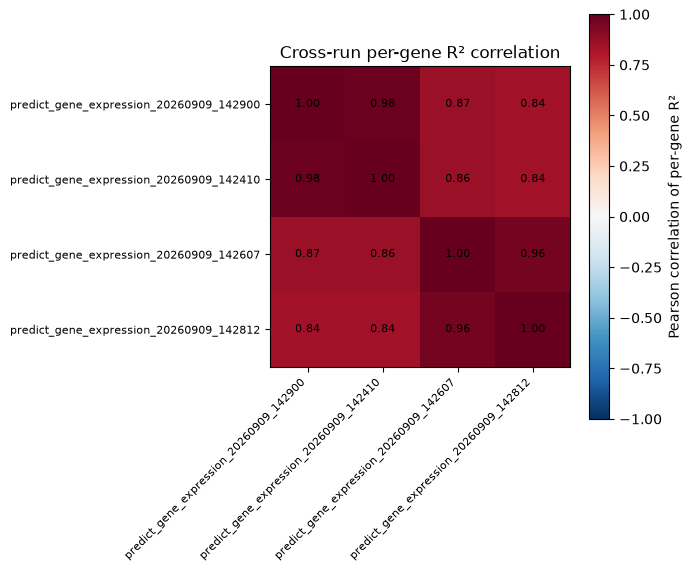

In [7]:
r2_by_run = None
for r in runs:
    s = r["per_gene_df"].set_index("gene")["r2"].rename(r["name"])
    r2_by_run = s.to_frame() if r2_by_run is None else r2_by_run.join(s, how="outer")

corr = r2_by_run.corr()

fig, ax = plt.subplots(figsize=(1.2 * len(runs) + 2, 1.2 * len(runs) + 2))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, shrink=0.8, label="Pearson correlation of per-gene R²")
ax.set_title("Cross-run per-gene R² correlation")
plt.tight_layout()
plt.show()